# Анализ и визуализация результатов финального Fine-tuning на Benchmark-выборке: 4 стратегии и Scratch

### Импорты и базовые настройки

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

In [46]:
COLORS = {
    "scratch": "black",
    "partial_ft": "pink",
    "warmup": "purple",
    "full_ft": "blue",
    "low_lr_encoder": "red"
}

STRATEGY_RU = {
    "scratch": "Обучение с нуля",
    "full_ft": "Полный fine-tuning",
    "low_lr_encoder": "Замедленное дообучение энкодера",
    "partial_ft": "Частичный fine-tuning",
    "warmup": "Двухэтапное дообучение энкодера",
}

STRATEGY_ORDER = [
    "scratch",
    "full_ft",
    "low_lr_encoder",
    "partial_ft",
    "warmup",
]

### Пути

In [3]:
# === INPUT PATHS ===

NOTEBOOK_DIR = Path.cwd()

PROJECT_ROOT = NOTEBOOK_DIR.parents[2]  

OUTPUTS_DIR = PROJECT_ROOT / "outputs"  / "downstream" / "test"

FIG_DIR = OUTPUTS_DIR / "figures"
TAB_DIR = OUTPUTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

FT_CSV = TAB_DIR / 'FT_strategies_summary.csv'
SCRATCH_CSV = TAB_DIR / 'Scratch_summary.csv'

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FT_CSV exists:", FT_CSV.exists(), FT_CSV)
print("SCRATCH_CSV exists:", SCRATCH_CSV.exists(), SCRATCH_CSV)
print("Output dir:", OUTPUTS_DIR.resolve())

FT_CSV exists: True c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\tables\FT_strategies_summary.csv
SCRATCH_CSV exists: True c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\tables\Scratch_summary.csv
Output dir: C:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test


### Загрузка файлов

In [6]:
df_ft = pd.read_csv(FT_CSV)
df_scratch = pd.read_csv(SCRATCH_CSV)

print("df_ft shape:", df_ft.shape)
print("df_scratch shape:", df_scratch.shape)

display(df_ft.head())
display(df_scratch.head())

df_ft shape: (1464, 28)
df_scratch shape: (366, 33)


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,warmup_epochs,selected_threshold,val_f1_at_selected_threshold,n_calib,n_val,n_test,n_pos_calib,n_pos_val,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr
0,subj_051,benchmark,0,ssl_ft,full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.5,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.534952,0.117603,0.210456,0.117603,1.000000,0.017394
1,subj_051,benchmark,0,ssl_ft,low_lr_encoder,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.5,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.534952,0.117603,0.210456,0.117603,1.000000,0.017394
2,subj_051,benchmark,0,ssl_ft,partial_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.5,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.534952,0.117603,0.210456,0.117603,1.000000,0.017394
3,subj_051,benchmark,0,ssl_ft,warmup,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,3.0,0.5,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.534952,0.117603,0.210456,0.117603,1.000000,0.017394
4,subj_051,benchmark,10,ssl_ft,full_ft,42,/kaggle/input/datasets/taisiyaglazova/ssl-full...,0.00003,0.0003,0.001,NaN,0.4,0.222222,623,125,2670,74,15,314,5.0,0.671958,15.0,0.508474,0.167790,0.212057,0.119314,0.952229,0.004054


,subject_id,group,p,scenario,ft_strategy,seed,encoder_checkpoint,lr_encoder,lr_head,weight_decay,warmup_epochs,selected_threshold,val_f1_at_selected_threshold,n_calib,n_val,n_test,n_pos_calib,n_pos_val,n_pos_test,best_epoch,best_val_loss,stopped_epoch,auc,accuracy,f1,precision,recall,fdr,run_tag,history_path,predictions_path,status,error
0,subj_051,benchmark,0,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.50,NaN,0,0,2670,0,0,314,NaN,NaN,NaN,0.499638,0.882397,0.000000,0.000000,0.000000,0.006737,benchmark__subj_051__p0__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
1,subj_051,benchmark,10,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.40,0.254545,623,125,2670,74,15,314,6.0,0.674627,16.0,0.550267,0.330337,0.217163,0.125888,0.789809,0.021560,benchmark__subj_051__p10__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
2,subj_051,benchmark,20,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.39,0.240964,1246,250,2670,148,30,314,3.0,0.686443,13.0,0.547048,0.245693,0.213281,0.121549,0.869427,0.018001,benchmark__subj_051__p20__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
3,subj_051,benchmark,40,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.40,0.233010,2492,499,2670,296,59,314,2.0,0.693760,12.0,0.563142,0.351685,0.213539,0.124536,0.748408,0.032400,benchmark__subj_051__p40__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN
4,subj_051,benchmark,60,scratch,NaN,42,NaN,0.00003,0.0003,0.001,NaN,0.05,0.212664,3738,748,2670,444,89,314,1.0,0.704080,11.0,0.551749,0.117603,0.210456,0.117603,1.000000,0.008633,benchmark__subj_051__p60__scratch__seed42,/kaggle/working/stage5_block2_results/stage5_f...,/kaggle/working/stage5_block2_results/stage5_f...,ok,NaN


In [4]:
print("FT columns:")
print(df_ft.columns.tolist())

print("\nScratch columns:")
print(df_scratch.columns.tolist())

FT columns:
['subject_id', 'group', 'p', 'scenario', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr']

Scratch columns:
['subject_id', 'group', 'p', 'scenario', 'ft_strategy', 'seed', 'encoder_checkpoint', 'lr_encoder', 'lr_head', 'weight_decay', 'warmup_epochs', 'selected_threshold', 'val_f1_at_selected_threshold', 'n_calib', 'n_val', 'n_test', 'n_pos_calib', 'n_pos_val', 'n_pos_test', 'best_epoch', 'best_val_loss', 'stopped_epoch', 'auc', 'accuracy', 'f1', 'precision', 'recall', 'fdr', 'run_tag', 'history_path', 'predictions_path', 'status', 'error']


### Приведение с единому формату и Объединение таблиц (только нужные признаки)

In [7]:
# --- копии ---
df_ft = df_ft.copy()
df_scratch = df_scratch.copy()

# --- создаём strategy ---
df_ft["strategy"] = df_ft["ft_strategy"].astype(str)
df_scratch["strategy"] = "scratch"

# --- приводим p ---
df_ft["p"] = df_ft["p"].astype(int)
df_scratch["p"] = df_scratch["p"].astype(int)

# --- оставляем только нужные колонки ---
core_cols = [
    "subject_id",
    "p",
    "strategy",
    "auc",
    "f1",
    "accuracy",
    "precision",
    "recall",
    "fdr"
]

optional_cols = ["group"]  # можно убрать, если не нужен

keep_cols = core_cols + optional_cols

df_ft = df_ft[keep_cols]
df_scratch = df_scratch[keep_cols]

# --- объединяем ---
df_all = pd.concat([df_ft, df_scratch], ignore_index=True)

print("df_all shape:", df_all.shape)
display(df_all.head())

df_all shape: (1830, 10)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group
0,subj_051,0,full_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark
1,subj_051,0,low_lr_encoder,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark
2,subj_051,0,partial_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark
3,subj_051,0,warmup,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark
4,subj_051,10,full_ft,0.508474,0.212057,0.167790,0.119314,0.952229,0.004054,benchmark


#### Проверка базовых значений

In [7]:
print("Unique strategies:", sorted(df_all["strategy"].dropna().unique().tolist()))
print("Unique p:", sorted(df_all["p"].dropna().unique().tolist()))
print("Number of subjects:", df_all["subject_id"].nunique())

Unique strategies: ['full_ft', 'low_lr_encoder', 'partial_ft', 'scratch', 'warmup']
Unique p: [0, 10, 20, 40, 60, 100]
Number of subjects: 61


#### Проверка ключевых метрик и обязательных колонок

In [8]:
required_cols = [
    "subject_id", "p", "strategy",
    "auc", "f1", "accuracy", "precision", "recall", "fdr"
]

missing_required = [c for c in required_cols if c not in df_all.columns]
print("Missing required columns:", missing_required)

Missing required columns: []


#### Проверка дубликатов по ключу subject_id × p × strategy

In [9]:
key_cols = ["subject_id", "p", "strategy"]

dup_mask = df_all.duplicated(subset=key_cols, keep=False)
df_dups = df_all.loc[dup_mask].sort_values(key_cols)

print("Number of duplicated rows by key:", len(df_dups))
display(df_dups.head(20))

Number of duplicated rows by key: 0


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group


#### Проверка пропусков в метриках

In [10]:
metric_cols = ["auc", "f1", "accuracy", "precision", "recall", "fdr"]

na_report = df_all[metric_cols].isna().sum().sort_values(ascending=False)
print("NaN counts in metrics:")
display(na_report.to_frame("n_missing"))

NaN counts in metrics:


,n_missing
auc,0
f1,0
accuracy,0
precision,0
recall,0
fdr,0


In [11]:
# Проверка пропусков по стратегиям
na_by_strategy = df_all.groupby("strategy")[metric_cols].apply(lambda x: x.isna().sum())
display(na_by_strategy)

,auc,f1,accuracy,precision,recall,fdr
strategy,,,,,,
full_ft,0,0,0,0,0,0
low_lr_encoder,0,0,0,0,0,0
partial_ft,0,0,0,0,0,0
scratch,0,0,0,0,0,0
warmup,0,0,0,0,0,0


#### Проверка числа наблюдений по стратегиям и по p

In [14]:
count_by_strategy_p = (
    df_all.groupby(["strategy", "p"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

display(count_by_strategy_p)

p,0,10,20,40,60,100
strategy,,,,,,
full_ft,61,61,61,61,61,61
low_lr_encoder,61,61,61,61,61,61
partial_ft,61,61,61,61,61,61
scratch,61,61,61,61,61,61
warmup,61,61,61,61,61,61


#### Проверка парности по субъектам

In [9]:
subjects_by_strategy_p = (
    df_all.groupby(["strategy", "p"])["subject_id"]
    .apply(lambda s: set(s.tolist()))
)

all_strategies = sorted(df_all["strategy"].unique())
all_p = sorted(df_all["p"].unique())

pairing_report = []

for p in all_p:
    base_subjects = subjects_by_strategy_p.get(("scratch", p), set())
    for strategy in all_strategies:
        cur_subjects = subjects_by_strategy_p.get((strategy, p), set())
        pairing_report.append({
            "p": p,
            "strategy": strategy,
            "n_subjects": len(cur_subjects),
            "same_as_scratch": cur_subjects == base_subjects,
            "missing_vs_scratch": len(base_subjects - cur_subjects),
            "extra_vs_scratch": len(cur_subjects - base_subjects),
        })

pairing_report_df = pd.DataFrame(pairing_report).sort_values(["p", "strategy"])
display(pairing_report_df)

,p,strategy,n_subjects,same_as_scratch,missing_vs_scratch,extra_vs_scratch
0,0,full_ft,61,True,0,0
1,0,low_lr_encoder,61,True,0,0
2,0,partial_ft,61,True,0,0
3,0,scratch,61,True,0,0
4,0,warmup,61,True,0,0
5,10,full_ft,61,True,0,0
6,10,low_lr_encoder,61,True,0,0
7,10,partial_ft,61,True,0,0
8,10,scratch,61,True,0,0
9,10,warmup,61,True,0,0


### Сохраняем промежуточную объединённую таблицу

In [ ]:
# df_all.to_csv(TAB_DIR / "combined_all_results.csv", index=False)
# pairing_report_df.to_csv(TAB_DIR / "pairing_report.csv", index=False)
# count_by_strategy_p.to_csv(TAB_DIR / "count_by_strategy_p.csv")

### Короткий автоматический sanity-check

In [8]:
expected_strategies = {"scratch", "full_ft", "low_lr_encoder", "partial_ft", "warmup"}
expected_p = {0, 10, 20, 40, 60, 100}

actual_strategies = set(df_all["strategy"].dropna().unique())
actual_p = set(df_all["p"].dropna().unique())

print("Strategies OK:", actual_strategies == expected_strategies)
print("p values OK:", actual_p == expected_p)
print("No duplicate keys:", len(df_dups) == 0)
print("No missing metrics:", df_all[metric_cols].isna().sum().sum() == 0)

Strategies OK: True
p values OK: True


NameError: name 'df_dups' is not defined

## Формирование финальной аналитической таблицы

#### Базовая агрегация

In [15]:
metric_cols = ["auc", "f1", "accuracy", "precision", "recall", "fdr"]

summary = (
    df_all
    .groupby(["strategy", "p"])[metric_cols]
    .agg(["mean", "std", "median"])
)

# flatten columns
summary.columns = ["_".join(col) for col in summary.columns]

# добавим число субъектов
n_subjects = (
    df_all
    .groupby(["strategy", "p"])["subject_id"]
    .nunique()
    .rename("n_subjects")
)

summary = summary.join(n_subjects)

summary = summary.reset_index()

display(summary.head())

,strategy,p,auc_mean,auc_std,auc_median,f1_mean,f1_std,f1_median,accuracy_mean,accuracy_std,accuracy_median,precision_mean,precision_std,precision_median,recall_mean,recall_std,recall_median,fdr_mean,fdr_std,fdr_median,n_subjects
0,full_ft,0,0.495105,0.030357,0.492960,0.225901,0.078746,0.209900,0.130088,0.053221,0.117256,0.129665,0.052767,0.117256,0.999197,0.003345,1.000000,0.004458,0.010227,0.001157,61
1,full_ft,10,0.508116,0.059916,0.503242,0.227546,0.083138,0.209900,0.198807,0.148726,0.118089,0.132988,0.056178,0.117256,0.926083,0.162400,1.000000,0.030876,0.187230,0.001176,61
2,full_ft,20,0.518442,0.066739,0.504963,0.228766,0.076179,0.210436,0.214437,0.157689,0.117743,0.135433,0.056029,0.117603,0.910941,0.140591,1.000000,0.039819,0.208470,0.001681,61
3,full_ft,40,0.548179,0.083461,0.530779,0.240477,0.098017,0.212172,0.257790,0.172983,0.234457,0.145515,0.079108,0.119565,0.887708,0.136328,0.933934,0.091484,0.397129,0.005781,61
4,full_ft,60,0.566530,0.088679,0.543837,0.245694,0.102865,0.210456,0.291573,0.199062,0.234601,0.151124,0.085095,0.117647,0.866630,0.168626,0.929539,0.131896,0.532602,0.010672,61


#### Отдельная таблица mean ± std

In [16]:
def mean_std_str(mean, std):
    return f"{mean:.4f} ± {std:.4f}"

table_mean_std = summary.copy()

for m in ["auc", "f1", "accuracy"]:
    table_mean_std[f"{m}_mean_std"] = table_mean_std.apply(
        lambda row: mean_std_str(row[f"{m}_mean"], row[f"{m}_std"]),
        axis=1
    )

cols_for_table = [
    "strategy", "p", "n_subjects",
    "auc_mean_std",
    "f1_mean_std",
    "accuracy_mean_std"
]

table_mean_std = table_mean_std[cols_for_table]

display(table_mean_std)

,strategy,p,n_subjects,auc_mean_std,f1_mean_std,accuracy_mean_std
0,full_ft,0,61,0.4951 ± 0.0304,0.2259 ± 0.0787,0.1301 ± 0.0532
1,full_ft,10,61,0.5081 ± 0.0599,0.2275 ± 0.0831,0.1988 ± 0.1487
2,full_ft,20,61,0.5184 ± 0.0667,0.2288 ± 0.0762,0.2144 ± 0.1577
3,full_ft,40,61,0.5482 ± 0.0835,0.2405 ± 0.0980,0.2578 ± 0.1730
4,full_ft,60,61,0.5665 ± 0.0887,0.2457 ± 0.1029,0.2916 ± 0.1991
5,full_ft,100,61,0.6245 ± 0.1171,0.2784 ± 0.1193,0.3942 ± 0.2366
6,low_lr_encoder,0,61,0.4951 ± 0.0304,0.2259 ± 0.0787,0.1301 ± 0.0532
7,low_lr_encoder,10,61,0.5140 ± 0.0600,0.2304 ± 0.0841,0.1941 ± 0.1334
8,low_lr_encoder,20,61,0.5239 ± 0.0626,0.2316 ± 0.0831,0.1898 ± 0.1255
9,low_lr_encoder,40,61,0.5318 ± 0.0668,0.2329 ± 0.0845,0.1961 ± 0.1347


#### Pivot-таблица

In [17]:
pivot_auc = table_mean_std.pivot(index="p", columns="strategy", values="auc_mean_std")
pivot_f1 = table_mean_std.pivot(index="p", columns="strategy", values="f1_mean_std")
pivot_acc = table_mean_std.pivot(index="p", columns="strategy", values="accuracy_mean_std")

print("AUC:")
display(pivot_auc)

print("\nF1:")
display(pivot_f1)

print("\nAccuracy:")
display(pivot_acc)

AUC:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.4951 ± 0.0304,0.4951 ± 0.0304,0.4951 ± 0.0304,0.5027 ± 0.0216,0.4951 ± 0.0304
10,0.5081 ± 0.0599,0.5140 ± 0.0600,0.5154 ± 0.0618,0.5145 ± 0.0555,0.5211 ± 0.0571
20,0.5184 ± 0.0667,0.5239 ± 0.0626,0.5315 ± 0.0646,0.5232 ± 0.0564,0.5274 ± 0.0617
40,0.5482 ± 0.0835,0.5318 ± 0.0668,0.5411 ± 0.0728,0.5357 ± 0.0589,0.5354 ± 0.0664
60,0.5665 ± 0.0887,0.5405 ± 0.0743,0.5508 ± 0.0784,0.5416 ± 0.0586,0.5458 ± 0.0733
100,0.6245 ± 0.1171,0.5518 ± 0.0803,0.5699 ± 0.0859,0.5560 ± 0.0695,0.5615 ± 0.0823



F1:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.2259 ± 0.0787,0.2259 ± 0.0787,0.2259 ± 0.0787,0.0000 ± 0.0000,0.2259 ± 0.0787
10,0.2275 ± 0.0831,0.2304 ± 0.0841,0.2306 ± 0.0845,0.2302 ± 0.0821,0.2303 ± 0.0845
20,0.2288 ± 0.0762,0.2316 ± 0.0831,0.2315 ± 0.0809,0.2287 ± 0.0803,0.2306 ± 0.0825
40,0.2405 ± 0.0980,0.2329 ± 0.0845,0.2366 ± 0.0866,0.2312 ± 0.0831,0.2325 ± 0.0841
60,0.2457 ± 0.1029,0.2363 ± 0.0880,0.2385 ± 0.0880,0.2313 ± 0.0829,0.2349 ± 0.0858
100,0.2784 ± 0.1193,0.2385 ± 0.0904,0.2462 ± 0.0949,0.2353 ± 0.0855,0.2423 ± 0.0957



Accuracy:


strategy,full_ft,low_lr_encoder,partial_ft,scratch,warmup
p,,,,,
0,0.1301 ± 0.0532,0.1301 ± 0.0532,0.1301 ± 0.0532,0.8703 ± 0.0528,0.1301 ± 0.0532
10,0.1988 ± 0.1487,0.1941 ± 0.1334,0.1904 ± 0.1350,0.1828 ± 0.1329,0.2018 ± 0.1373
20,0.2144 ± 0.1577,0.1898 ± 0.1255,0.2367 ± 0.1495,0.2035 ± 0.1464,0.1974 ± 0.1341
40,0.2578 ± 0.1730,0.1961 ± 0.1347,0.2256 ± 0.1598,0.2185 ± 0.1344,0.1999 ± 0.1276
60,0.2916 ± 0.1991,0.2058 ± 0.1544,0.2447 ± 0.1634,0.2015 ± 0.1275,0.2165 ± 0.1418
100,0.3942 ± 0.2366,0.2257 ± 0.1575,0.2890 ± 0.1868,0.2099 ± 0.1430,0.2451 ± 0.1719


#### Сохраняем таблицы

In [ ]:
# summary.to_csv(TAB_DIR / "summary_full_stats.csv", index=False)
# table_mean_std.to_csv(TAB_DIR / "summary_mean_std.csv", index=False)

# pivot_auc.to_csv(TAB_DIR / "pivot_auc.csv")
# pivot_f1.to_csv(TAB_DIR / "pivot_f1.csv")
# pivot_acc.to_csv(TAB_DIR / "pivot_accuracy.csv")

## Основные графики

- ROC-AUC vs p
- F1 vs p
- Accuracy vs p

#### Подготовка данных для графиков

In [18]:
plot_df = (
    df_all
    .groupby(["strategy", "p"])[["auc", "f1", "accuracy"]]
    .agg(["mean", "std"])
)

plot_df.columns = ["_".join(col) for col in plot_df.columns]
plot_df = plot_df.reset_index()

display(plot_df.head())

,strategy,p,auc_mean,auc_std,f1_mean,f1_std,accuracy_mean,accuracy_std
0,full_ft,0,0.495105,0.030357,0.225901,0.078746,0.130088,0.053221
1,full_ft,10,0.508116,0.059916,0.227546,0.083138,0.198807,0.148726
2,full_ft,20,0.518442,0.066739,0.228766,0.076179,0.214437,0.157689
3,full_ft,40,0.548179,0.083461,0.240477,0.098017,0.257790,0.172983
4,full_ft,60,0.566530,0.088679,0.245694,0.102865,0.291573,0.199062


#### Функция для построения графика

In [18]:
def make_strategy_label(row):
    scenario = row.get("scenario", None)
    ft_strategy = row.get("ft_strategy", None)

    if scenario == "scratch":
        return "С нуля"
    if pd.notna(ft_strategy):
        return STRATEGY_RU.get(ft_strategy, str(ft_strategy))
    return str(scenario)

In [36]:
def draw_metric_plot(metric, ylabel):
    plt.figure(figsize=(7, 5))

    p_values = [0, 10, 20, 40, 60, 100]

    strategies_present = [
        s for s in STRATEGY_ORDER
        if s in plot_df["strategy"].unique()
    ]

    for strategy in strategies_present:
        sub = plot_df[plot_df["strategy"] == strategy].copy()
        sub = sub.set_index("p").loc[p_values].reset_index()

        x = sub["p"]
        y = sub[f"{metric}_mean"]
        yerr = sub[f"{metric}_std"]

        linestyle = "--" if strategy == "scratch" else "-"

        plt.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            color=COLORS[strategy],
            label=STRATEGY_RU.get(strategy, strategy),
        )

        plt.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

    plt.xticks(p_values)
    plt.xlabel("Объём калибровки p (%)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} в зависимости от объёма калибровки")
    plt.legend(title="Стратегия")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

#### Строим графики

In [37]:
def plot_metric(metric, ylabel):
    draw_metric_plot(metric, ylabel)
    plt.show()

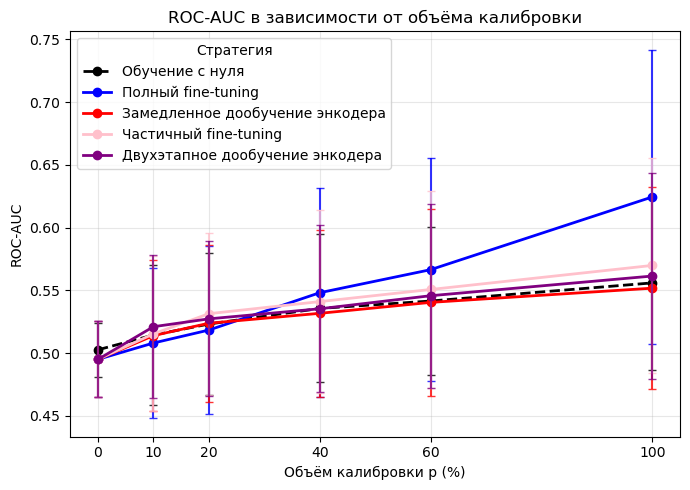

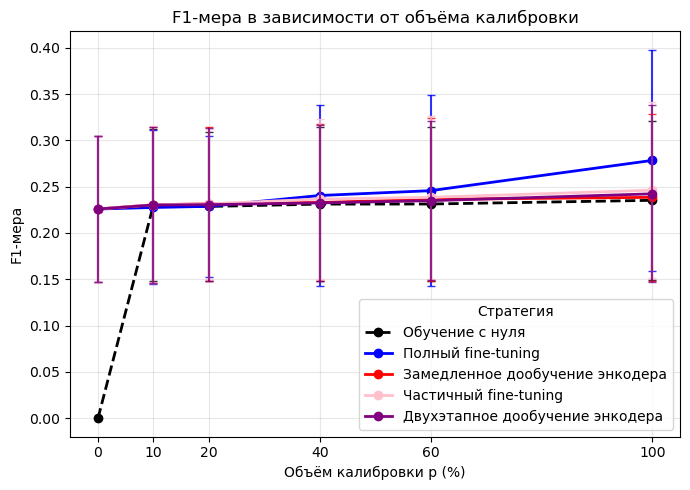

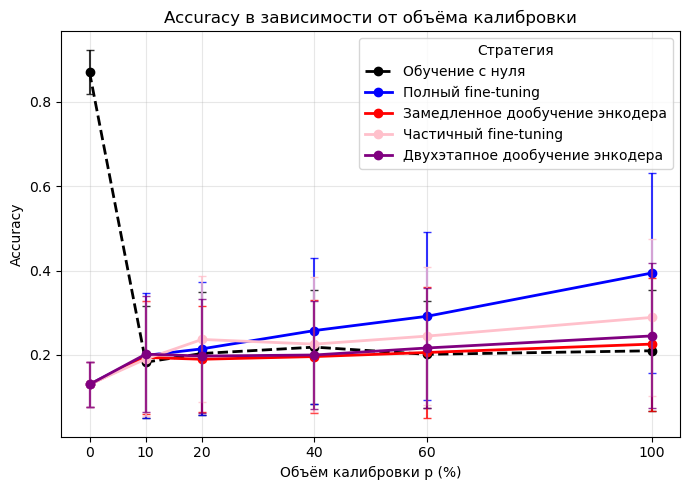

In [38]:
plot_metric("auc", "ROC-AUC")
plot_metric("f1", "F1-мера")
plot_metric("accuracy", "Accuracy")

In [25]:
def plot_clean(metric, ylabel):
    plt.figure(figsize=(7, 5))

    p_values = [0, 10, 20, 40, 60, 100]

    for strategy in sorted(plot_df["strategy"].unique()):
        sub = plot_df[plot_df["strategy"] == strategy]
        sub = sub.set_index("p").loc[p_values].reset_index()

        linestyle = "--" if strategy == "scratch" else "-"

        plt.plot(
            sub["p"],
            sub[f"{metric}_mean"],
            marker="o",
            color=COLORS[strategy],
            linewidth=2,
            linestyle=linestyle,
            label=STRATEGY_RU.get(strategy, strategy),
        )

    plt.xticks(p_values)
    plt.xlabel("Объём калибровки p (%)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} в зависимости от объёма калибровки")

    plt.legend(title="Стратегия")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

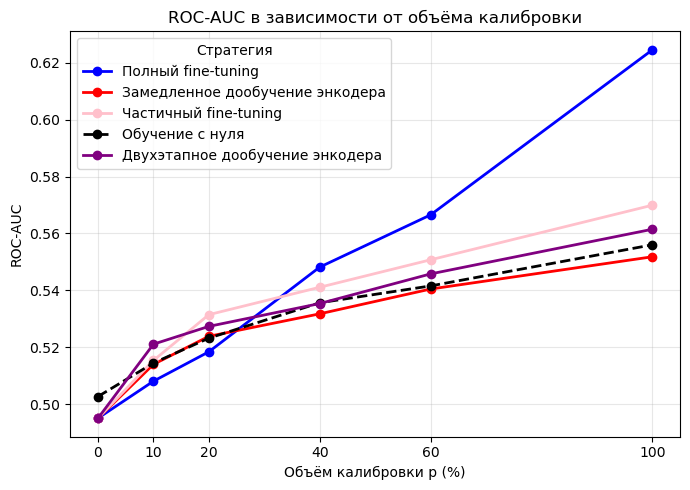

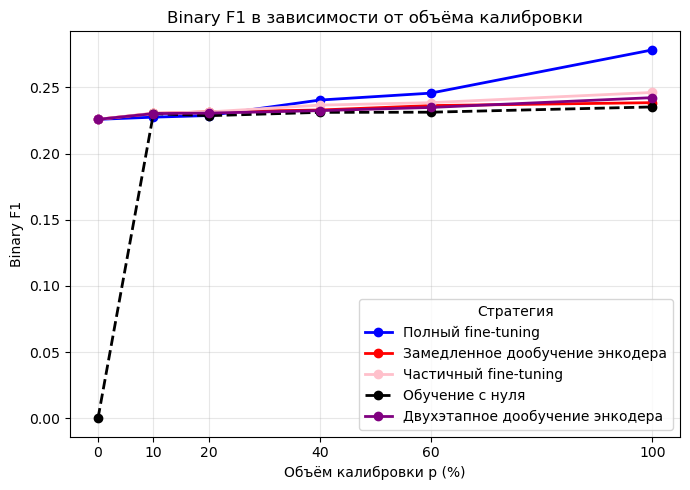

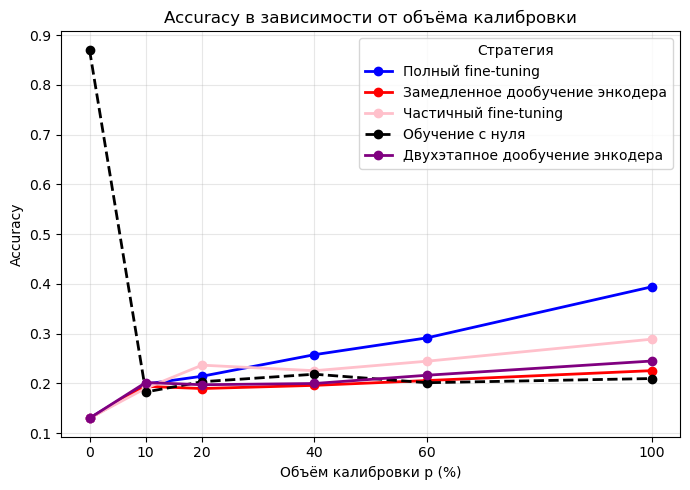

In [26]:
plot_clean("auc", "ROC-AUC")
plot_clean("f1", "Binary F1")
plot_clean("accuracy", "Accuracy")

#### Сохраняем графики

In [24]:
def save_plot(plot_func, metric, ylabel, filename):
    fig = plot_func(metric, ylabel)

    save_path = FIG_DIR / filename
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    fig.savefig(save_path.with_suffix(".pdf"), bbox_inches="tight")
    plt.close(fig)

    print(f"Сохранено: {save_path}")

In [ ]:
save_plot(draw_metric_plot, "auc", "ROC-AUC", "auc_vs_p.png")
save_plot(draw_metric_plot, "f1", "F1-мера", "f1_vs_p.png")
save_plot(draw_metric_plot, "accuracy", "Accuracy", "accuracy_vs_p.png")

Сохранено: analysis_outputs\figures\auc_vs_p.png
Сохранено: analysis_outputs\figures\f1_vs_p.png
Сохранено: analysis_outputs\figures\accuracy_vs_p.png


In [ ]:
def save_clean_plot(metric, ylabel, filename):
    plt.figure(figsize=(7, 5))

    p_values = [0, 10, 20, 40, 60, 100]

    for strategy in sorted(plot_df["strategy"].unique()):
        sub = plot_df[plot_df["strategy"] == strategy]
        sub = sub.set_index("p").loc[p_values].reset_index()

        if strategy == "scratch":
            linestyle = "--"
            linewidth = 3
        else:
            linestyle = "-"
            linewidth = 2

        plt.plot(
            sub["p"],
            sub[f"{metric}_mean"],
            marker="o",
            linestyle=linestyle,
            linewidth=linewidth,
            color=COLORS[strategy],
            label=strategy
        )

    plt.xticks(p_values)
    plt.xlabel("Calibration size p (%)")
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} vs Calibration Size")

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIG_DIR / filename, dpi=300)
    plt.close()

In [32]:
save_clean_plot("auc", "ROC-AUC", "clean_auc_vs_p.png")
save_clean_plot("f1", "Binary F1", "clean_f1_vs_p.png")
save_clean_plot("accuracy", "Accuracy", "clean_accuracy_vs_p.png")

## Графики выигрыша относительно scratch

#### per-subject delta

In [4]:
df_all = pd.read_csv(TAB_DIR / "combined_all_results.csv")

In [5]:
metric_cols = ["auc", "f1", "accuracy"]

# scratch как база
df_scratch_base = (
    df_all[df_all["strategy"] == "scratch"]
    [["subject_id", "p"] + metric_cols]
    .rename(columns={m: f"{m}_scratch" for m in metric_cols})
    .copy()
)

# все не-scratch стратегии
df_non_scratch = df_all[df_all["strategy"] != "scratch"].copy()

# merge по subject_id и p
df_delta = df_non_scratch.merge(
    df_scratch_base,
    on=["subject_id", "p"],
    how="inner"
)

# считаем дельты
for m in metric_cols:
    df_delta[f"delta_{m}"] = df_delta[m] - df_delta[f"{m}_scratch"]

print("df_delta shape:", df_delta.shape)
display(df_delta.head())

df_delta shape: (1464, 16)


,subject_id,p,strategy,auc,f1,accuracy,precision,recall,fdr,group,auc_scratch,f1_scratch,accuracy_scratch,delta_auc,delta_f1,delta_accuracy
0,subj_051,0,full_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.499638,0.000000,0.882397,0.035314,0.210456,-0.764794
1,subj_051,0,low_lr_encoder,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.499638,0.000000,0.882397,0.035314,0.210456,-0.764794
2,subj_051,0,partial_ft,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.499638,0.000000,0.882397,0.035314,0.210456,-0.764794
3,subj_051,0,warmup,0.534952,0.210456,0.117603,0.117603,1.000000,0.017394,benchmark,0.499638,0.000000,0.882397,0.035314,0.210456,-0.764794
4,subj_051,10,full_ft,0.508474,0.212057,0.167790,0.119314,0.952229,0.004054,benchmark,0.550267,0.217163,0.330337,-0.041793,-0.005106,-0.162547


In [6]:
check_delta = (
    df_delta.groupby(["strategy", "p"])[["delta_auc", "delta_f1", "delta_accuracy"]]
    .agg(["mean", "std", "median"])
)

check_delta.columns = ["_".join(col) for col in check_delta.columns]
check_delta = check_delta.reset_index()

display(check_delta)

,strategy,p,delta_auc_mean,delta_auc_std,delta_auc_median,delta_f1_mean,delta_f1_std,delta_f1_median,delta_accuracy_mean,delta_accuracy_std,delta_accuracy_median
0,full_ft,0,-0.007618,0.032961,-0.013236,0.225901,0.078746,0.209900,-0.740226,0.106011,-0.765488
1,full_ft,10,-0.006366,0.038922,-0.001568,-0.002652,0.010547,0.000000,0.015994,0.162274,0.000000
2,full_ft,20,-0.004796,0.040320,-0.004641,0.000115,0.015398,0.000000,0.010971,0.137315,0.000000
3,full_ft,40,0.012519,0.049472,0.009975,0.009302,0.043941,0.001642,0.039276,0.122632,0.018430
4,full_ft,60,0.024956,0.045298,0.015071,0.014405,0.061145,0.001616,0.090120,0.179002,0.019683
5,full_ft,100,0.068460,0.087189,0.042894,0.043103,0.070019,0.010160,0.184362,0.209897,0.094907
6,low_lr_encoder,0,-0.007618,0.032961,-0.013236,0.225901,0.078746,0.209900,-0.740226,0.106011,-0.765488
7,low_lr_encoder,10,-0.000468,0.036930,0.006326,0.000190,0.007247,0.000000,0.011300,0.126325,0.000000
8,low_lr_encoder,20,0.000640,0.033840,-0.000311,0.002923,0.011345,0.000000,-0.013699,0.107126,0.000000
9,low_lr_encoder,40,-0.003884,0.039007,0.002141,0.001767,0.007952,0.000383,-0.022370,0.103829,-0.003017


#### Функция для delta-графика

In [19]:
def plot_delta_metric(delta_metric, ylabel):
    fig, ax = plt.subplots(figsize=(7, 5))

    p_values = [10, 20, 40, 60, 100]

    strategies_present = [
        s for s in STRATEGY_ORDER
        if s in df_delta["strategy"].unique()
    ]

    for strategy in strategies_present:
        sub = (
            df_delta[df_delta["strategy"] == strategy]
            .groupby("p")[delta_metric]
            .agg(["mean", "std"])
            .reset_index()
            .set_index("p")
            .loc[p_values]
            .reset_index()
        )

        x = sub["p"]
        y = sub["mean"]
        yerr = sub["std"]

        linestyle = "--" if strategy == "scratch" else "-"

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            color=COLORS[strategy],
            label=STRATEGY_RU.get(strategy, strategy),
        )

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xticks(p_values)
    ax.set_xlabel("Объём калибровки p (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} относительно Scratch")
    ax.legend(title="Стратегия")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    return fig

#### Строим Δ-графики

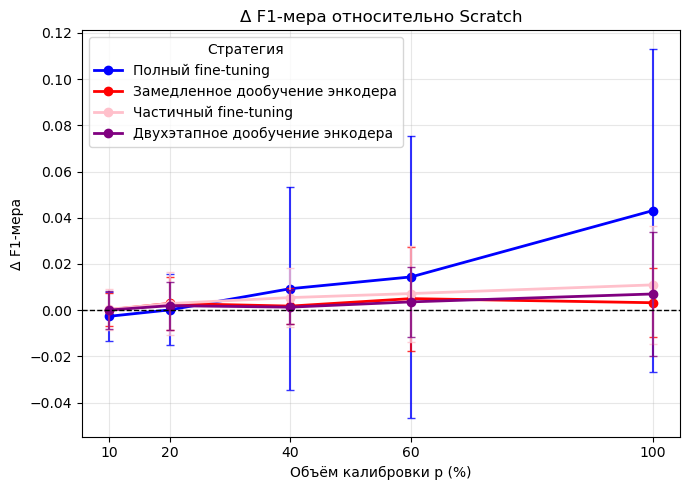

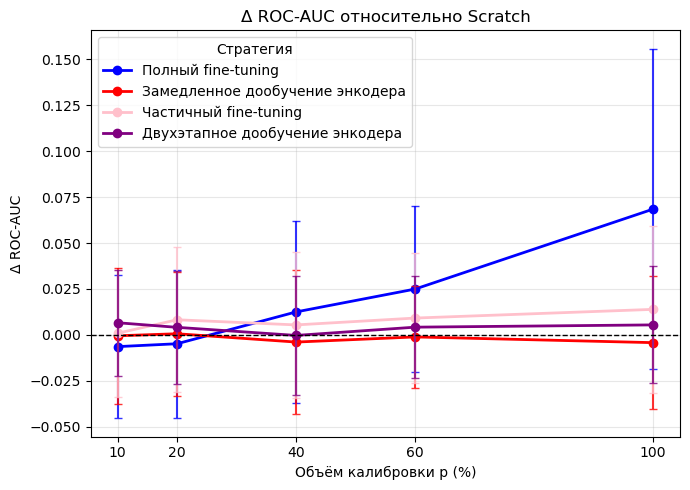

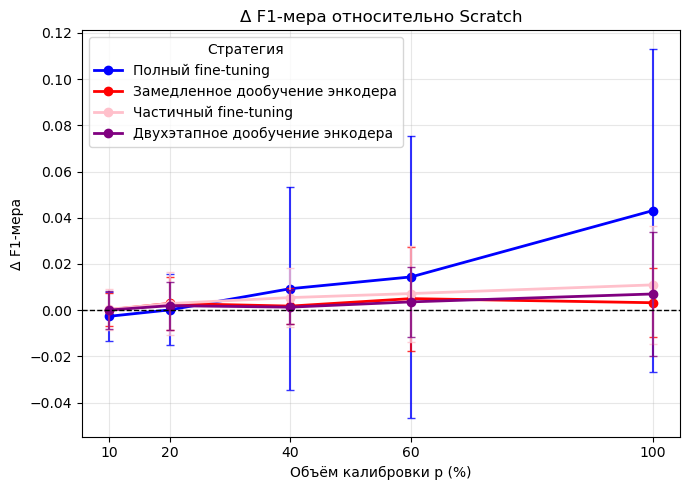

In [21]:
plot_delta_metric("delta_auc",  "Δ ROC-AUC")
plot_delta_metric("delta_f1", "Δ F1-мера")

#### Сохраняем Δ-графики

In [25]:
save_plot(plot_delta_metric, "delta_auc", "Δ ROC-AUC", "delta_auc_vs_p_new.png")
save_plot(plot_delta_metric, "delta_f1", "Δ F1-мера", "delta_f1_vs_scratch_new.png")
save_plot(plot_delta_metric, "delta_accuracy", "Δ Accuracy", "delta_accuracy_vs_scratch_new.png")

Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\figures\delta_auc_vs_p_new.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\figures\delta_f1_vs_scratch_new.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\figures\delta_accuracy_vs_scratch_new.png


## Парные статистические тесты

In [7]:
# Импорт статистики
from scipy.stats import wilcoxon

#### Функция для одного теста

In [10]:
def run_wilcoxon(df, metric, alternative="two-sided"):
    values = df[metric].dropna()

    if len(values) < 5:
        return np.nan

    try:
        stat, p = wilcoxon(values, alternative=alternative)
        return p
    except Exception:
        return np.nan

#### Запускаем тесты

In [11]:
results = []

strategies = sorted(df_delta["strategy"].unique())
p_values = sorted(df_delta["p"].unique())

metrics = ["delta_auc", "delta_f1", "delta_accuracy"]

for p in p_values:
    for strategy in strategies:
        sub = df_delta[
            (df_delta["p"] == p) &
            (df_delta["strategy"] == strategy)
        ]

        for metric in metrics:
            p_val = run_wilcoxon(sub, metric)

            results.append({
                "p": p,
                "strategy": strategy,
                "metric": metric,
                "n": len(sub),
                "mean": sub[metric].mean(),
                "median": sub[metric].median(),
                "p_value": p_val
            })

stats_df = pd.DataFrame(results)
display(stats_df.head())

,p,strategy,metric,n,mean,median,p_value
0,0,full_ft,delta_auc,61,-0.007618,-0.013236,4.205307e-03
1,0,full_ft,delta_f1,61,0.225901,0.209900,1.109647e-11
2,0,full_ft,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11
3,0,low_lr_encoder,delta_auc,61,-0.007618,-0.013236,4.205307e-03
4,0,low_lr_encoder,delta_f1,61,0.225901,0.209900,1.109647e-11


#### Поправка на множественные сравнения

In [ ]:
from statsmodels.stats.multitest import multipletests

stats_df["p_adj"] = multipletests(stats_df["p_value"], method="fdr_bh")[1]
stats_df["significant"] = stats_df["p_adj"] < 0.05

# display(stats_df)

#### Сохраняем таблицу стат анализа

In [13]:
stats_df.to_excel(TAB_DIR / "DELTAvsSCRATCH_STAT_ANALYSIS.xlsx", index=False)

In [27]:
stats_df.head()

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
0,0,full_ft,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True
1,0,full_ft,delta_f1,61,0.225901,0.209900,1.109647e-11,9.986827e-11,True
2,0,full_ft,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11,9.986827e-11,True
3,0,low_lr_encoder,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True
4,0,low_lr_encoder,delta_f1,61,0.225901,0.209900,1.109647e-11,9.986827e-11,True


#### Только значимые строки

In [15]:
significant_df = stats_df[stats_df["significant"] == True]

display(significant_df)

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
0,0,full_ft,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True
1,0,full_ft,delta_f1,61,0.225901,0.209900,1.109647e-11,9.986827e-11,True
2,0,full_ft,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11,9.986827e-11,True
3,0,low_lr_encoder,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True
4,0,low_lr_encoder,delta_f1,61,0.225901,0.209900,1.109647e-11,9.986827e-11,True
5,0,low_lr_encoder,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11,9.986827e-11,True
6,0,partial_ft,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True
7,0,partial_ft,delta_f1,61,0.225901,0.209900,1.109647e-11,9.986827e-11,True
8,0,partial_ft,delta_accuracy,61,-0.740226,-0.765488,1.109647e-11,9.986827e-11,True
9,0,warmup,delta_auc,61,-0.007618,-0.013236,4.205307e-03,1.261592e-02,True


#### Только по AUC

In [53]:
sig_auc_positive = stats_df[
    (stats_df["metric"] == "delta_auc") &
    (stats_df["significant"] == True) &
    (stats_df["mean"] > 0)
]

display(sig_auc_positive.sort_values(["p", "strategy"]))

,p,strategy,metric,n,mean,median,p_value,p_adj,significant
48,60,full_ft,delta_auc,61,0.024956,0.015071,1.661775e-05,0.000100,True
60,100,full_ft,delta_auc,61,0.068460,0.042894,2.028157e-07,0.000001,True


In [54]:
for strategy in sorted(sig_auc_positive["strategy"].unique()):
    p_list = sig_auc_positive[sig_auc_positive["strategy"] == strategy]["p"].tolist()
    print(f"{strategy}: significant improvement at p = {p_list}")

full_ft: significant improvement at p = [60, 100]


#### Графики со звёздочками

In [56]:
def p_to_stars(p_adj):
    if p_adj < 0.001:
        return "***"
    elif p_adj < 0.01:
        return "**"
    elif p_adj < 0.05:
        return "*"
    return ""


def plot_delta_metric(delta_metric, ylabel, stats_df):
    fig, ax = plt.subplots(figsize=(9, 5))

    p_values = [10, 20, 40, 60, 100]

    strategies_present = [
        s for s in STRATEGY_ORDER
        if s in df_delta["strategy"].unique()
    ]

    plotted_points = {}

    for strategy in strategies_present:
        sub = (
            df_delta[df_delta["strategy"] == strategy]
            .groupby("p")[delta_metric]
            .agg(["mean", "std"])
            .reset_index()
            .set_index("p")
            .loc[p_values]
            .reset_index()
        )

        x = sub["p"]
        y = sub["mean"]
        yerr = sub["std"]

        linestyle = "--" if strategy == "scratch" else "-"

        ax.plot(
            x,
            y,
            marker="o",
            linewidth=2,
            linestyle=linestyle,
            color=COLORS[strategy],
            label=STRATEGY_RU.get(strategy, strategy),
        )

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

        plotted_points[strategy] = sub

    # --- значимые улучшения ---
    sig_sub = stats_df[
        (stats_df["metric"] == delta_metric)
        & (stats_df["p"].isin(p_values))
        & (stats_df["strategy"].isin(strategies_present))
        & (stats_df["mean"] > 0)
        & (stats_df["p_adj"] < 0.05)
    ].copy()

    y_all = df_delta[df_delta["p"].isin(p_values)][delta_metric]
    y_range = y_all.max() - y_all.min()

    base_offset = 0.06 * y_range if y_range > 0 else 0.01
    step = 0.04 * y_range if y_range > 0 else 0.01

    max_star_y = None

    for p in p_values:
        # верхняя граница самого длинного уса для данного p
        y_tops = []

        for strategy in strategies_present:
            sub = plotted_points[strategy]
            row = sub[sub["p"] == p]

            if row.empty:
                continue

            y_value = row["mean"].values[0]
            y_std = row["std"].values[0]

            if np.isnan(y_std):
                y_std = 0

            y_tops.append(y_value + y_std)

        if not y_tops:
            continue

        y_top = max(y_tops)

        # значимые улучшения для данного p
        sig_p = sig_sub[sig_sub["p"] == p].copy()

        if sig_p.empty:
            continue

        # стабильный порядок стратегий как в STRATEGY_ORDER
        sig_p["strategy_order"] = sig_p["strategy"].apply(
            lambda s: strategies_present.index(s)
        )
        sig_p = sig_p.sort_values("strategy_order")

        n = len(sig_p)

        for i, (_, row) in enumerate(sig_p.iterrows()):
            strategy = row["strategy"]
            stars = p_to_stars(row["p_adj"])

            if stars == "":
                continue

            # инверсия порядка (сверху вниз)
            star_y = y_top + base_offset + (n - 1 - i) * step

            ax.text(
                p,
                star_y,
                stars,
                ha="center",
                va="bottom",
                fontsize=12,
                fontweight="bold",
                color=COLORS[strategy],
            )

            max_star_y = star_y if max_star_y is None else max(max_star_y, star_y)

    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    ax.set_xticks(p_values)
    ax.set_xlabel("Объём калибровки p (%)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} относительно Scratch")
    ax.legend(title="Стратегия")
    ax.grid(True, alpha=0.3)

    # запас сверху, чтобы звёздочки не обрезались
    ymin, ymax = ax.get_ylim()

    if max_star_y is not None:
        ymax = max(ymax, max_star_y + 0.08 * y_range)

    ax.set_ylim(ymin, ymax)

    fig.tight_layout()
    return fig

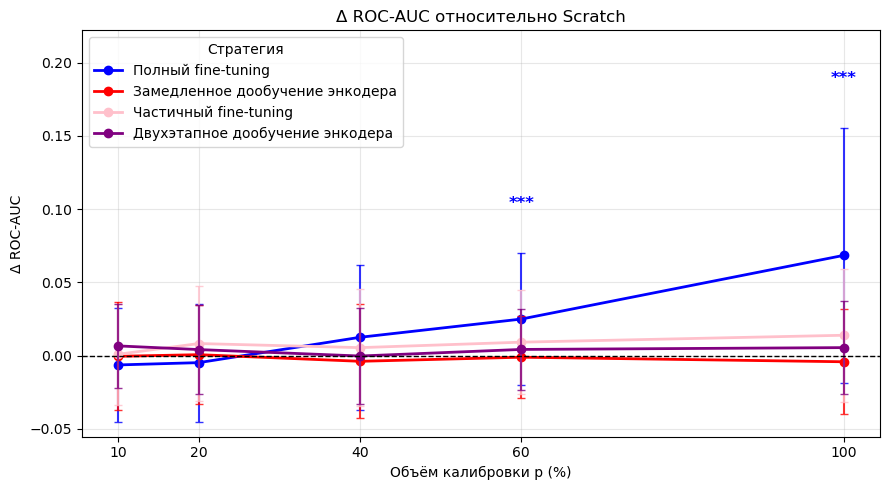

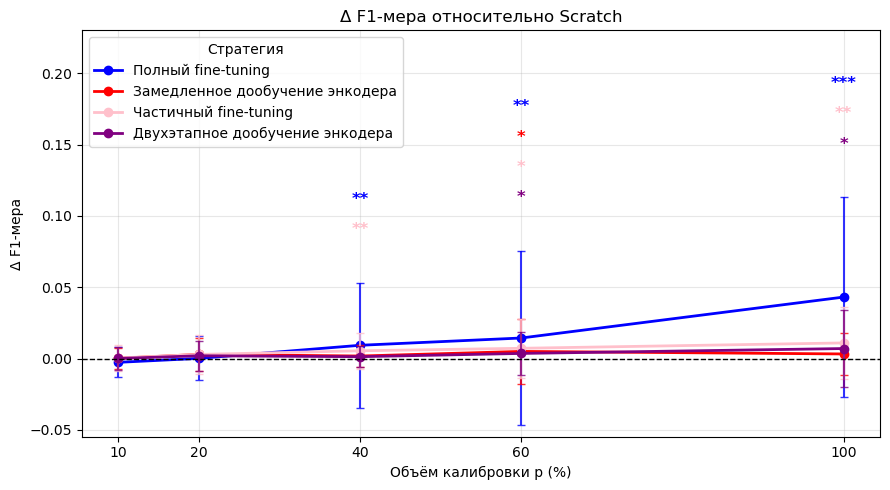

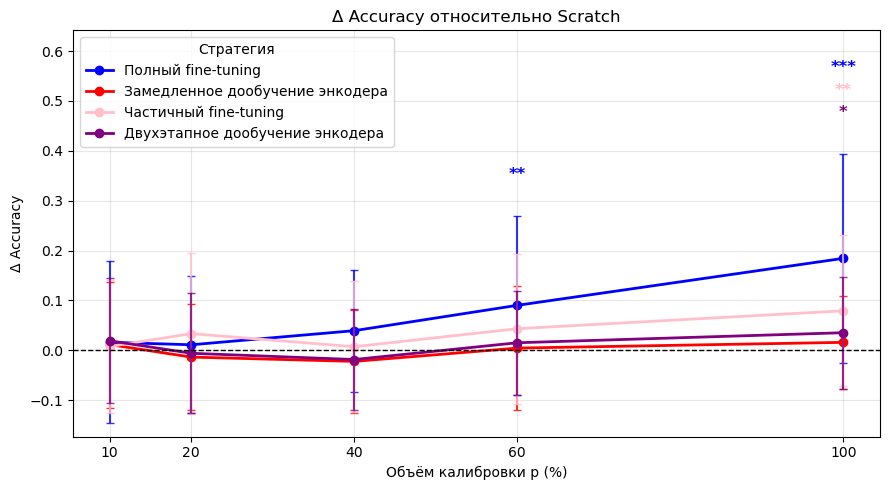

In [57]:
fig = plot_delta_metric("delta_auc", "Δ ROC-AUC", stats_df)
fig = plot_delta_metric("delta_f1", "Δ F1-мера", stats_df)
fig = plot_delta_metric("delta_accuracy", "Δ Accuracy", stats_df)

In [59]:
def save_plot_STAT(plot_func, metric, ylabel, stats_df, filename):
    fig = plot_func(metric, ylabel, stats_df)

    save_path = FIG_DIR / filename
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Сохранено: {save_path}")

In [60]:
save_plot_STAT(plot_delta_metric, "delta_auc", "Δ ROC-AUC", stats_df, "delta_auc_vs_p_STAT.png")
save_plot_STAT(plot_delta_metric, "delta_f1", "Δ F1-мера", stats_df, "delta_f1_vs_scratch_STAT.png")
save_plot_STAT(plot_delta_metric, "delta_accuracy", "Δ Accuracy", stats_df, "delta_accuracy_vs_scratch_STAT.png")

Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\figures\delta_auc_vs_p_STAT.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\figures\delta_f1_vs_scratch_STAT.png
Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\figures\delta_accuracy_vs_scratch_STAT.png


## Одна общая таблица для разных объёмв калибровки

In [61]:
df_all = pd.read_csv(TAB_DIR / "combined_all_results.csv")


In [62]:
from statsmodels.stats.multitest import multipletests
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon

def run_wilcoxon2(values, alternative="two-sided"):
    values = pd.Series(values).dropna()

    if len(values) < 5:
        return np.nan

    try:
        stat, p = wilcoxon(values, alternative=alternative)
        return p
    except Exception:
        return np.nan

def build_reference(df_all, p_ref):
    return (
        df_all[
            (df_all["strategy"] == "scratch") &
            (df_all["p"] == p_ref)
        ][["subject_id", "auc", "f1", "accuracy"]]
        .rename(columns={
            "auc": f"auc_scratch{p_ref}",
            "f1": f"f1_scratch{p_ref}",
            "accuracy": f"accuracy_scratch{p_ref}"
        })
        .copy()
    )


def compare_with_reference(df_all, p_ref):
    metric_cols = ["auc", "f1", "accuracy"]

    df_ref = build_reference(df_all, p_ref)
    df_ssl = df_all[df_all["strategy"] != "scratch"].copy()

    df_cmp = df_ssl.merge(df_ref, on="subject_id", how="inner")

    for m in metric_cols:
        df_cmp[f"delta_vs_scratch{p_ref}_{m}"] = (
            df_cmp[m] - df_cmp[f"{m}_scratch{p_ref}"]
        )

    return df_cmp


def build_stats_vs_scratch_refs(df_all, p_refs=[100, 60, 40, 20]):
    metric_cols = ["auc", "f1", "accuracy"]
    all_results = []

    for p_ref in p_refs:
        df_cmp = compare_with_reference(df_all, p_ref=p_ref)

        for (strategy, p), sub in df_cmp.groupby(["strategy", "p"]):
            for m in metric_cols:
                delta_col = f"delta_vs_scratch{p_ref}_{m}"
                vals = sub[delta_col].dropna()

                all_results.append({
                    "strategy": strategy,
                    "p": p,
                    "p_ref": p_ref,
                    "metric": m,
                    "n": len(vals),
                    "mean_diff": vals.mean(),
                    "std_diff": vals.std(),
                    "median_diff": vals.median(),
                    "frac_ge_0": (vals >= 0).mean(),
                    "p_value": run_wilcoxon2(vals),
                })

    stats_all_refs = pd.DataFrame(all_results)

    # Поправка BH отдельно внутри каждой метрики
    # Так аккуратнее, чем смешивать auc/f1/accuracy в одну поправку
    stats_all_refs["p_adj"] = np.nan

    for metric, idx in stats_all_refs.groupby("metric").groups.items():
        pvals = stats_all_refs.loc[idx, "p_value"].values
        stats_all_refs.loc[idx, "p_adj"] = multipletests(
            pvals,
            method="fdr_bh"
        )[1]

    stats_all_refs["significant"] = stats_all_refs["p_adj"] < 0.05

    return stats_all_refs

In [64]:
stats_all_refs = build_stats_vs_scratch_refs(
    df_all,
    p_refs=[100, 60, 40, 20]
)

display(stats_all_refs.head())

,strategy,p,p_ref,metric,n,mean_diff,std_diff,median_diff,frac_ge_0,p_value,p_adj,significant
0,full_ft,0,100,auc,61,-0.060910,0.058414,-0.050561,0.049180,3.798159e-11,9.115580e-10,True
1,full_ft,0,100,f1,61,-0.009375,0.042870,-0.000240,0.442623,8.946100e-03,2.221154e-02,True
2,full_ft,0,100,accuracy,61,-0.079785,0.137958,-0.028326,0.131148,2.259767e-10,5.423441e-09,True
3,full_ft,10,100,auc,61,-0.047899,0.055387,-0.036762,0.114754,1.435135e-09,1.059792e-08,True
4,full_ft,10,100,f1,61,-0.007729,0.025327,-0.000616,0.360656,1.880061e-03,7.998815e-03,True


In [65]:
def make_calibration_matrix(stats_all_refs, metric="auc"):
    strategies = [
        "full_ft",
        "low_lr_encoder",
        "partial_ft",
        "warmup",
    ]

    p_ssl_values = [10, 20, 40, 60]
    p_ref_values = [100, 60, 40, 20]

    df_stat = stats_all_refs[stats_all_refs["metric"] == metric].copy()

    def format_cell(row):
        return (
            f"Δ={row['mean_diff']:.3f}\n"
            f"med = {row['median_diff']:.3f}\n"
            f"p={row['p_adj']:.3g}\n"
            f"({row['frac_ge_0']:.2f})"
        )

    rows = []

    for strategy in strategies:
        for p_ssl in p_ssl_values:
            row_out = {
                "strategy": strategy,
                "p_ssl": f"p={p_ssl}%",
            }

            for p_ref in p_ref_values:
                col_name = f"scratch p={p_ref}%"

                # пустые клетки, где сравнение не имеет смысла
                if p_ssl >= p_ref:
                    row_out[col_name] = ""
                    continue

                sub = df_stat[
                    (df_stat["strategy"] == strategy)
                    & (df_stat["p"] == p_ssl)
                    & (df_stat["p_ref"] == p_ref)
                ]

                if sub.empty:
                    row_out[col_name] = ""
                else:
                    row_out[col_name] = format_cell(sub.iloc[0])

            rows.append(row_out)

    return pd.DataFrame(rows)

In [66]:
table_auc = make_calibration_matrix(stats_all_refs, metric="auc")
table_f1 = make_calibration_matrix(stats_all_refs, metric="f1")
table_acc = make_calibration_matrix(stats_all_refs, metric="accuracy")

display(table_auc)

,strategy,p_ssl,scratch p=100%,scratch p=60%,scratch p=40%,scratch p=20%
0,full_ft,p=10%,Δ=-0.048\nmed = -0.037\np=1.06e-08\n(0.11),Δ=-0.033\nmed = -0.028\np=6.71e-07\n(0.18),Δ=-0.028\nmed = -0.022\np=1.23e-05\n(0.26),Δ=-0.015\nmed = -0.005\np=0.0103\n(0.41)
1,full_ft,p=20%,Δ=-0.038\nmed = -0.023\np=1.03e-07\n(0.15),Δ=-0.023\nmed = -0.016\np=0.000202\n(0.28),Δ=-0.017\nmed = -0.007\np=0.0146\n(0.38),
2,full_ft,p=40%,Δ=-0.008\nmed = -0.006\np=0.234\n(0.38),Δ=0.007\nmed = 0.004\np=0.278\n(0.62),,
3,full_ft,p=60%,Δ=0.011\nmed = 0.003\np=0.0559\n(0.56),,,
4,low_lr_encoder,p=10%,Δ=-0.042\nmed = -0.031\np=7.67e-09\n(0.10),Δ=-0.028\nmed = -0.022\np=2.61e-06\n(0.26),Δ=-0.022\nmed = -0.013\np=0.000609\n(0.36),Δ=-0.009\nmed = -0.004\np=0.111\n(0.43)
5,low_lr_encoder,p=20%,Δ=-0.032\nmed = -0.023\np=2.94e-07\n(0.16),Δ=-0.018\nmed = -0.013\np=0.000102\n(0.33),Δ=-0.012\nmed = -0.008\np=0.0622\n(0.38),
6,low_lr_encoder,p=40%,Δ=-0.024\nmed = -0.013\np=0.000106\n(0.33),Δ=-0.010\nmed = -0.008\np=0.0903\n(0.41),,
7,low_lr_encoder,p=60%,Δ=-0.016\nmed = -0.010\np=0.000204\n(0.33),,,
8,partial_ft,p=10%,Δ=-0.041\nmed = -0.026\np=1.23e-08\n(0.11),Δ=-0.026\nmed = -0.024\np=6.46e-06\n(0.26),Δ=-0.020\nmed = -0.016\np=0.000507\n(0.31),Δ=-0.008\nmed = -0.003\np=0.141\n(0.48)
9,partial_ft,p=20%,Δ=-0.025\nmed = -0.016\np=7.49e-06\n(0.23),Δ=-0.010\nmed = -0.005\np=0.0286\n(0.39),Δ=-0.004\nmed = -0.004\np=0.57\n(0.49),


In [67]:
out_path = TAB_DIR / "calibration_reduction_tables.xlsx"

with pd.ExcelWriter(out_path) as writer:
    table_auc.to_excel(writer, sheet_name="ROC-AUC", index=False)
    table_f1.to_excel(writer, sheet_name="F1", index=False)
    table_acc.to_excel(writer, sheet_name="Accuracy", index=False)

out_path

WindowsPath('c:/Users/Таисия/Desktop/МФТИ/Диплом_BCI/diploma-bciP300-ssl/outputs/downstream/test/tables/calibration_reduction_tables.xlsx')

In [71]:
metric = "auc"  # "auc" или "f1", "accuracy"

important_cells = stats_all_refs[
    (stats_all_refs["metric"] == metric) &
    ((stats_all_refs["mean_diff"] >= 0) |
    (stats_all_refs["median_diff"] >= 0))
].copy()

important_cells = important_cells[
    important_cells["p"] < important_cells["p_ref"]
]

important_cells = important_cells[important_cells["p"] > 0]

important_cells = important_cells[
    ["strategy", "p", "p_ref", "mean_diff", "median_diff", "p_adj", "frac_ge_0"]
].sort_values(["strategy", "p", "p_ref"])

for _, row in important_cells.iterrows():
    print(
        f"{row['strategy']} | p={row['p']} vs scratch p={row['p_ref']} → "
        f"Δ={row['mean_diff']:.3f}, med={row['median_diff']:.3f}, "
        f"p={row['p_adj']:.3g}, ({row['frac_ge_0']:.2f})"
    )

full_ft | p=40 vs scratch p=60 → Δ=0.007, med=0.004, p=0.278, (0.62)
full_ft | p=60 vs scratch p=100 → Δ=0.011, med=0.003, p=0.0559, (0.56)
warmup | p=10 vs scratch p=20 → Δ=-0.002, med=0.000, p=0.709, (0.52)


### Графики

In [72]:
def plot_delta_vs_scratch_ref(
    stats_all_refs,
    strategy,
    p_ref,
    metric="auc",
    p_values=(10, 20, 40, 60, 100),
    highlight_p=None,
    equal_band=0.01,
    save=False,
):
    fig, ax = plt.subplots(figsize=(8, 5))

    sub = stats_all_refs[
        (stats_all_refs["strategy"] == strategy)
        & (stats_all_refs["p_ref"] == p_ref)
        & (stats_all_refs["metric"] == metric)
        & (stats_all_refs["p"].isin(p_values))
    ].copy()

    sub = (
        sub
        .set_index("p")
        .reindex(p_values)
        .reset_index()
    )

    x = sub["p"]
    y = sub["mean_diff"]

    label = (
        f"'{STRATEGY_RU.get(strategy, strategy)}' "
        f"vs 'Обучение с нуля' (p={p_ref})"
    )

    ax.plot(
        x, y,
        marker="o",
        linewidth=2,
        color=COLORS[strategy],
        label=label,
    )

    # error bars если есть std
    if "std_diff" in sub.columns:
        yerr = sub["std_diff"]

        ax.errorbar(
            x, y,
            yerr=yerr,
            fmt="none",
            ecolor=COLORS[strategy],
            capsize=3,
            alpha=0.8,
        )

    ax.axhline(0, linestyle="--", linewidth=1, color="black")

    # зона равенства
    ax.axhspan(
        -equal_band,
        equal_band,
        color="gray",
        alpha=0.15,
        label=f"≈ одинаковое качество (±{equal_band})",
    )

    # выделение точки
    if highlight_p is not None and highlight_p in sub["p"].values:
        row_h = sub[sub["p"] == highlight_p].iloc[0]

        ax.scatter(
            highlight_p,
            row_h["mean_diff"],
            color="red",
            s=80,
            zorder=5,
            label=f"p={highlight_p}: без потери качества",
        )

    metric_ru = {
        "auc": "ROC-AUC",
        "f1": "F1-мера",
        "accuracy": "Accuracy",
    }.get(metric, metric)

    ax.set_xticks(list(p_values))
    ax.set_xlabel("Объём калибровки p (%)")
    ax.set_ylabel(f"Δ {metric_ru} относительно обучения с нуля (p={p_ref})")
    ax.set_title(
        f"{metric_ru}: {STRATEGY_RU.get(strategy, strategy)} vs Scratch (p={p_ref})"
    )

    ax.legend(title="Сравнение")
    ax.grid(True, alpha=0.3)

    fig.tight_layout()

    # --- автосохранение ---
    if save:
        metric_name = metric.lower()
        strategy_name = strategy.lower()
        filename = f"{metric_name}_{strategy_name}_vs_scratch{p_ref}.png"

        save_path = FIG_DIR / filename

        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)

        print(f"Сохранено: {save_path}")
    else:
        plt.show()

    return fig

#### Рисуем

STRATEGY_RU = {
    "scratch": "Обучение с нуля",
    "full_ft": "Полный fine-tuning",
    "low_lr_encoder": "Замедленное дообучение энкодера",
    "partial_ft": "Частичный fine-tuning",
    "warmup": "Двухэтапное дообучение энкодера",
}

Сохранено: c:\Users\Таисия\Desktop\МФТИ\Диплом_BCI\diploma-bciP300-ssl\outputs\downstream\test\figures\auc_warmup_vs_scratch20.png


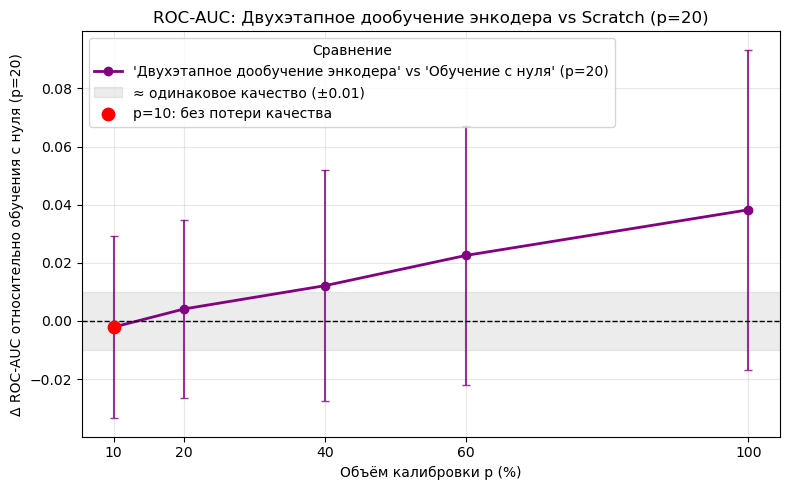

In [75]:
plot_delta_vs_scratch_ref(
    stats_all_refs,
    strategy="warmup",
    p_ref=20,
    metric="auc",
    highlight_p=10,
    save=True
)